https://people.cs.vt.edu/~naren/papers/EiNNs.pdf 

In [193]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np


class EpiParams(nn.Module):
    '''Пока только SIRD'''
    def __init__(self, population_n, init_params= None, device = 'cpu'):
        super().__init__()
        self.N = population_n
        self.device = device

        # значения по 
        ''' TODO понять бы откуда брать beta, mu 
        и как их начальные значения влияют на последующий результат'''
        if init_params is None:
            init_params = {'beta': 0.1, 'gamma': 0.01, 'mu': 0.0009}

        # Инициализация в логитовом пространстве (как в статье)
        def to_logit(x):
            # Случаи на границах, чтобы не уйти в бесконечность
            if x <= 0:
                x_adj = 1e-12
            elif x >= 1:
                x_adj = 1 - 1e-12
            else:
                x_adj = x
            
            return np.arctanh(2 * x_adj - 1)
        
        self.beta_latent = nn.Parameter(torch.tensor(to_logit(init_params['beta'])),requires_grad=True)
        self.gamma_latent = nn.Parameter(torch.tensor(to_logit(init_params['gamma'])),requires_grad=True)
        self.mu_latent = nn.Parameter(torch.tensor(to_logit(init_params['mu'])),requires_grad=True)

    @property
    def beta(self):
        """β ∈ [0,1]"""
        return (torch.tanh(self.beta_latent) + 1) * 0.5
    
    @property
    def gamma(self):
        """γ ∈ [0,1]"""
        return (torch.tanh(self.gamma_latent) + 1) * 0.5
    
    @property
    def mu(self):
        """μ ∈ [0,1]"""
        return (torch.tanh(self.mu_latent) + 1) * 0.5
    
    def get_params_dict(self):
        """Для логирования"""
        return {
            'beta': self.beta.item(),
            'gamma': self.gamma.item(),
            'mu': self.mu.item()
        } 
        

In [195]:
class TorchStandardScaler:
    def fit(self, x, device):
        x = torch.tensor(x).float().to(device)
        self.mean = x.mean(0, keepdim=True)
        self.std = x.std(0, unbiased=False, keepdim=True)

    def transform(self, x):
        if torch.is_tensor(x):
            x -= self.mean
            x /= (self.std + 1e-7)
        else:
            x -= self.mean.cpu().numpy()
            x /= (self.std + 1e-7).cpu().numpy()
        return x

    def fit_transform(self, x, device):
        self.fit(x, device)
        return self.transform(x)

    def inverse_transform(self, x):
        x *= self.std
        x += self.mean
        return x

In [189]:
class EINN_PINN(nn.Module):
    '''SIRD'''
    def __init__(self, t, S_data, I_data, R_data, D_data, population, train_size, device = 'cpu'):
        super().__init__()
        self.device = device
        self.N = population
        self.train_size = train_size
        # TODO инициализация весов дефолтная корректная? МБ xavier_uniform_ сделать?

        # Данные (оставляем как есть, в реальных единицах)
        self.t = torch.tensor(t, dtype=torch.float, device=device, requires_grad=True)
        self.S_data = torch.tensor(S_data, dtype=torch.float, device=device)
        self.I_data = torch.tensor(I_data, dtype=torch.float, device=device)
        self.R_data = torch.tensor(R_data, dtype=torch.float, device=device)
        self.D_data = torch.tensor(D_data, dtype=torch.float, device=device)

        # СОЗДАЕМ И ОБУЧАЕМ НОРМАЛАЙЗЕРЫ
        self.S_scaler = TorchStandardScaler()
        self.I_scaler = TorchStandardScaler()
        self.R_scaler = TorchStandardScaler()
        self.D_scaler = TorchStandardScaler()
        
        # Обучаем на тренировочных данных
        self.S_scaler.fit(self.S_data[:train_size].cpu().numpy(), device)
        self.I_scaler.fit(self.I_data[:train_size].cpu().numpy(), device)
        self.R_scaler.fit(self.R_data[:train_size].cpu().numpy(), device)
        self.D_scaler.fit(self.D_data[:train_size].cpu().numpy(), device)

        # Нейросеть для состояний (предсказывает в нормализованном пространстве)
        # TODO почему именно такая сеть?
        # степень двойки, чтобы лучше считать на CPU\GPU?
        self.state_net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 4)  # S, I, R, D
        ).to(device)

        self.params = EpiParams(self.N, device=device)

        # Параметры для оптимизации
        self.all_params =  list(self.state_net.parameters()) + list(self.params.parameters())

        self.losses = []

    def denormalize_states(self, states_norm):
        '''Из нормализованного в реальный масштаб'''
        S_norm, I_norm, R_norm, D_norm = states_norm[:, 0], states_norm[:, 1],  states_norm[:, 2],  states_norm[:, 3]

        S = self.S_scaler.inverse_transform(S_norm.reshape(-1, 1)).reshape(-1)
        I = self.I_scaler.inverse_transform(I_norm.reshape(-1, 1)).reshape(-1)
        R = self.R_scaler.inverse_transform(R_norm.reshape(-1, 1)).reshape(-1)
        D = self.D_scaler.inverse_transform(D_norm.reshape(-1, 1)).reshape(-1)

        # Гарантируется неотрицательность (физический смысл)
        # [0, +oo]
        S = F.softplus(S)
        I = F.softplus(I)
        R = F.softplus(R)
        D = F.softplus(D)
        
        return S, I, R, D

    def forward(self, t_batch):
        '''Прямой проход'''
        t_flat = t_batch.reshape(-1, 1)
        states_norm =  self.state_net(t_flat)
        return self.denormalize_states(states_norm)
    
    def compute_ode_residual(self, t_batch):
        '''Невязка по уравнениям SIRD в реальных единицах'''
        S, I, R, D = self.forward(t_batch)

        # Производные через autograd
        S_t = torch.autograd.grad(S.sum(), t_batch, create_graph = True)[0].squeeze()
        I_t = torch.autograd.grad(I.sum(), t_batch, create_graph = True)[0].squeeze()
        R_t = torch.autograd.grad(R.sum(), t_batch, create_graph = True)[0].squeeze()
        D_t = torch.autograd.grad(D.sum(), t_batch, create_graph = True)[0].squeeze()

        # Параметры эпидемии в реальных единицах
        beta, gamma, mu = self.params.beta, self.params.gamma, self.params.mu

        # Уравнения SIRD
        dS = - beta * I * S / self.N
        dI = beta * I * S / self.N - gamma * I - mu * I
        dR = gamma * I
        dD = mu * I

        # Расчет невязки
        f_S = S_t - dS
        f_I = I_t - dI
        f_R = R_t - dR
        f_D = D_t - dD

        return f_S, f_I, f_R, f_D, S, I, R, D

    def train_model(self, n_epoch = 20000, lambda_data = 1.0, lambda_ode = 0.1):
        '''Обучение модели'''
        optimizer = optim.Adam(self.all_params, lr = 1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1000, factor=0.5)
        t_batch = self.t.reshape(-1, 1).detach().requires_grad_(True)

        for epoch in range(n_epoch):
            optimizer.zero_grad()

            # Невязки ODE
            f_S, f_I, f_R, f_D, S, I, R, D = self.compute_ode_residual(t_batch)

            # Ошибка по данным (только на обучающей выборке)
            loss_data_S = F.mse_loss(S[:self.train_size], self.S_data[:self.train_size])
            loss_data_I = F.mse_loss(I[:self.train_size], self.I_data[:self.train_size])
            loss_data_R = F.mse_loss(R[:self.train_size], self.R_data[:self.train_size])
            loss_data_D = F.mse_loss(D[:self.train_size], self.D_data[:self.train_size])

            loss_data = loss_data_S + 10*loss_data_I + loss_data_R + loss_data_D

            # Невязка по уравнениям
            loss_ode = torch.mean(f_S**2 + f_I**2 + f_R**2 + f_D**2)

            # Общая потеря
            loss =  lambda_data * loss_data + lambda_ode * loss_ode

            loss.backward()
            optimizer.step()
            scheduler.step(loss)

            self.losses.append(loss.item())

            if epoch % 1000 == 0:
                params = self.params.get_params_dict()
                print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f} | '
                      f'Data: {loss_data.item():.6f} | ODE: {loss_ode.item():.6f}')
                print(f'Params: β={params["beta"]:.4f}, γ={params["gamma"]:.4f}, μ={params["mu"]:.4f}')
                print('---')

    def predict(self, t_values = None):
        '''Получение предсказаний'''
        if t_values is None:
            t_values = self.t.detach().cpu().numpy()

        t_batch = torch.tensor(t_values, dtype=torch.float, device= self.device).reshape(-1, 1)

        with torch.no_grad():
            S, I, R, D = self.forward(t_batch)

        return S.cpu(), I.cpu(), R.cpu(), D.cpu()

In [169]:
# Функция для отрисовки результатов
def plot_results(timesteps, train_size, 
                 S_data, I_data, R_data, D_data,
                 S_pred, I_pred, R_pred, D_pred,
                 params):
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('SIRD Model - PINN Prediction vs Real Data', fontsize=16)
    
    # Вертикальная линия разделяющая train/test
    train_test_line = train_size - 0.5
    
    # 1. Susceptible (S)
    ax = axes[0, 0]
    ax.plot(timesteps[:train_size], S_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], S_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, S_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Susceptible')
    ax.set_title(f'Susceptible (S)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Infected (I)
    ax = axes[0, 1]
    ax.plot(timesteps[:train_size], I_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], I_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, I_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Infected')
    ax.set_title(f'Infected (I)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Recovered (R)
    ax = axes[1, 0]
    ax.plot(timesteps[:train_size], R_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], R_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, R_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Recovered')
    ax.set_title(f'Recovered (R)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Dead (D)
    ax = axes[1, 1]
    ax.plot(timesteps[:train_size], D_data[:train_size], 'b.', label='Train Data', markersize=3)
    ax.plot(timesteps[train_size:], D_data[train_size:], 'g.', label='Test Data', markersize=3)
    ax.plot(timesteps, D_pred, 'r-', label='PINN Prediction', linewidth=2)
    ax.axvline(x=train_test_line, color='k', linestyle='--', alpha=0.7, label='Train/Test split')
    ax.set_xlabel('Time')
    ax.set_ylabel('Dead')
    ax.set_title(f'Dead (D)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('sird_prediction_results.png', dpi=150)
    plt.show()
    
    return fig

# Функция для отрисовки потерь
def plot_losses(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(losses, 'b-', alpha=0.7, linewidth=1)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss Over Time')
    plt.grid(True, alpha=0.3)
    # plt.savefig('training_loss.png', dpi=150)
    plt.show()

# Функция для вычисления метрик
def calculate_metrics(S_data, I_data, R_data, D_data, 
                     S_pred, I_pred, R_pred, D_pred, train_size):
    
    # Метрики на тестовой выборке
    test_mask = slice(train_size, None)
    
    mse_S = np.mean((S_data[test_mask] - S_pred[test_mask])**2)
    mse_I = np.mean((I_data[test_mask] - I_pred[test_mask])**2)
    mse_R = np.mean((R_data[test_mask] - R_pred[test_mask])**2)
    mse_D = np.mean((D_data[test_mask] - D_pred[test_mask])**2)
    
    mae_S = np.mean(np.abs(S_data[test_mask] - S_pred[test_mask]))
    mae_I = np.mean(np.abs(I_data[test_mask] - I_pred[test_mask]))
    mae_R = np.mean(np.abs(R_data[test_mask] - R_pred[test_mask]))
    mae_D = np.mean(np.abs(D_data[test_mask] - D_pred[test_mask]))
    
    print("\n" + "="*60)
    print("МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print(f"MSE - S: {mse_S:.2f}, I: {mse_I:.2f}, R: {mse_R:.2f}, D: {mse_D:.2f}")
    print(f"MAE - S: {mae_S:.2f}, I: {mae_I:.2f}, R: {mae_R:.2f}, D: {mae_D:.2f}")
    print("="*60)
    
    return {
        'mse': {'S': mse_S, 'I': mse_I, 'R': mse_R, 'D': mse_D},
        'mae': {'S': mae_S, 'I': mae_I, 'R': mae_R, 'D': mae_D}
    }

# Функция для отрисовки сравнения параметров (если есть истинные значения)
def plot_params_comparison(true_params, learned_params):
    if true_params is None:
        return
    
    params_names = ['β (transmission)', 'γ (recovery)', 'μ (mortality)']
    true_values = [true_params['beta'], true_params['gamma'], true_params['mu']]
    learned_values = [learned_params['beta'], learned_params['gamma'], learned_params['mu']]
    
    x = np.arange(len(params_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, true_values, width, label='True', alpha=0.8)
    bars2 = ax.bar(x + width/2, learned_values, width, label='Learned', alpha=0.8)
    
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Values')
    ax.set_title('True vs Learned Parameters')
    ax.set_xticks(x)
    ax.set_xticklabels(params_names)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    # plt.savefig('params_comparison.png', dpi=150)
    plt.show()

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

# Загрузка данных
covid_cases = pd.read_csv('./real_datasets/covid-19_Kouprianov.csv')
# covid_cases = pd.read_csv('./synthetic_datasets/01_baseline_constant.csv')
# covid_cases = pd.read_csv('sird_data_01_006_0003.csv')
# covid_cases = pd.read_csv('simulation.csv')

# Получаем данные
S = covid_cases['S'].values
I = covid_cases['I'].values
D = covid_cases['D'].values
R = covid_cases['R'].values
timesteps = np.arange(len(S)).astype(float)

# Параметры
train_size = 180  # размер обучающей выборки
population = S[0] + I[0] + R[0] + D[0]  # Общая популяция в начале

print(f"Всего точек данных: {len(timesteps)}")
print(f"Обучающих точек: {train_size}")
print(f"Тестовых точек: {len(timesteps) - train_size}")

Using device: cuda
Всего точек данных: 369
Обучающих точек: 180
Тестовых точек: 189


In [197]:
# Создание и обучение модели
model = EINN_PINN(
    t=timesteps,
    S_data=S,
    I_data=I,
    R_data=R,
    D_data=D,
    population=population,
    train_size=train_size,
    device=device
)

# Обучение модели
print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*60)
model.train_model(n_epoch=10000, lambda_data=0.1, lambda_ode=1.0)

# Получение финальных параметров
final_params = model.params.get_params_dict()
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ ПАРАМЕТРЫ ЭПИДЕМИИ:")
print(f"β (transmission rate) = {final_params['beta']:.6f}")
print(f"γ (recovery rate) = {final_params['gamma']:.6f}")
print(f"μ (mortality rate) = {final_params['mu']:.6f}")
print("="*60)

# Предсказание для всех временных точек
S_pred, I_pred, R_pred, D_pred = model.predict(timesteps)

# Преобразуем в numpy для удобства
S_pred = S_pred.numpy()
I_pred = I_pred.numpy()
R_pred = R_pred.numpy()
D_pred = D_pred.numpy()



НАЧАЛО ОБУЧЕНИЯ
Epoch     0 | Loss: 1048314752.000000 | Data: 10417409024.000000 | ODE: 6573808.000000
Params: β=0.1000, γ=0.0100, μ=0.0009
---
Epoch  1000 | Loss: 119228624.000000 | Data: 708505280.000000 | ODE: 48378100.000000
Params: β=0.0790, γ=0.0132, μ=0.0012
---
Epoch  2000 | Loss: 53338664.000000 | Data: 193573056.000000 | ODE: 33981356.000000
Params: β=0.0664, γ=0.0163, μ=0.0015
---
Epoch  3000 | Loss: 17773168.000000 | Data: 39757140.000000 | ODE: 13797453.000000
Params: β=0.0588, γ=0.0190, μ=0.0018
---
Epoch  4000 | Loss: 8254875.000000 | Data: 34316460.000000 | ODE: 4823229.000000
Params: β=0.0547, γ=0.0213, μ=0.0020
---
Epoch  5000 | Loss: 3480454.000000 | Data: 11230999.000000 | ODE: 2357354.250000
Params: β=0.0520, γ=0.0238, μ=0.0023
---
Epoch  6000 | Loss: 2423617.500000 | Data: 9421845.000000 | ODE: 1481433.125000
Params: β=0.0499, γ=0.0266, μ=0.0025
---
Epoch  7000 | Loss: 1872211.750000 | Data: 8020512.000000 | ODE: 1070160.625000
Params: β=0.0481, γ=0.0293, μ=0.002


Отрисовка результатов...


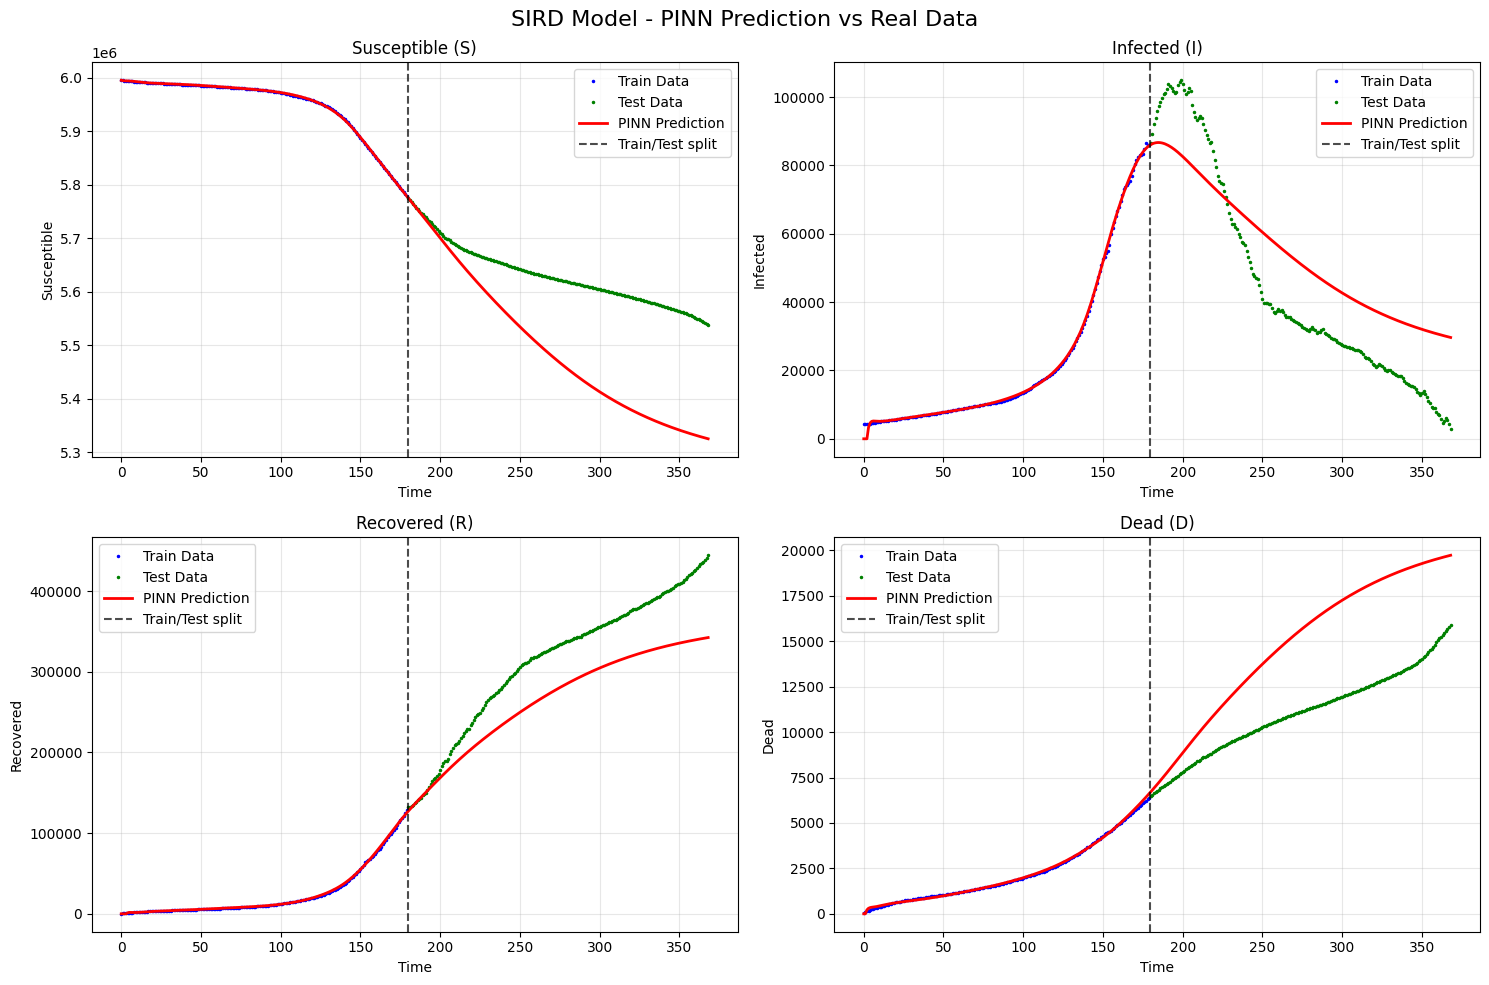

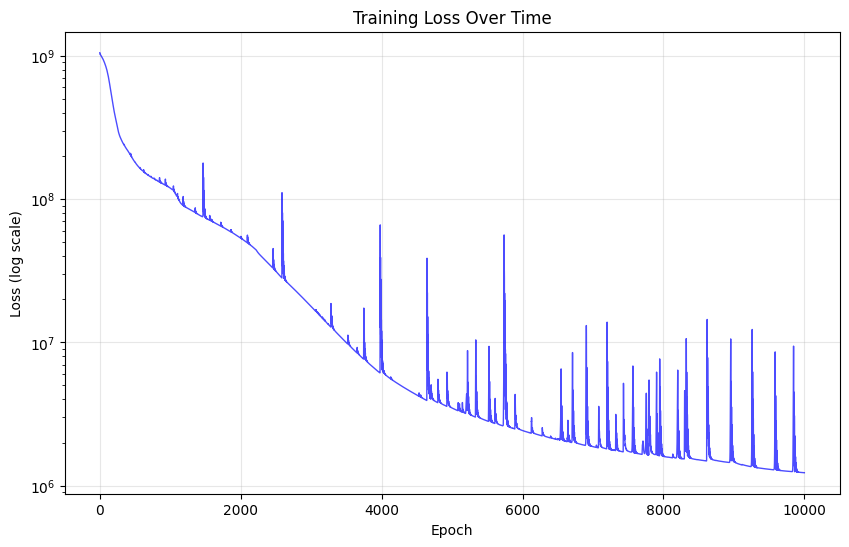


МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
MSE - S: 24044418453.70, I: 266128329.00, R: 2811197923.98, D: 17008455.16
MAE - S: 133291.21, I: 15516.77, R: 47943.62, D: 3755.26

Готово! Результаты сохранены:
- sird_prediction_results.png
- training_loss.png


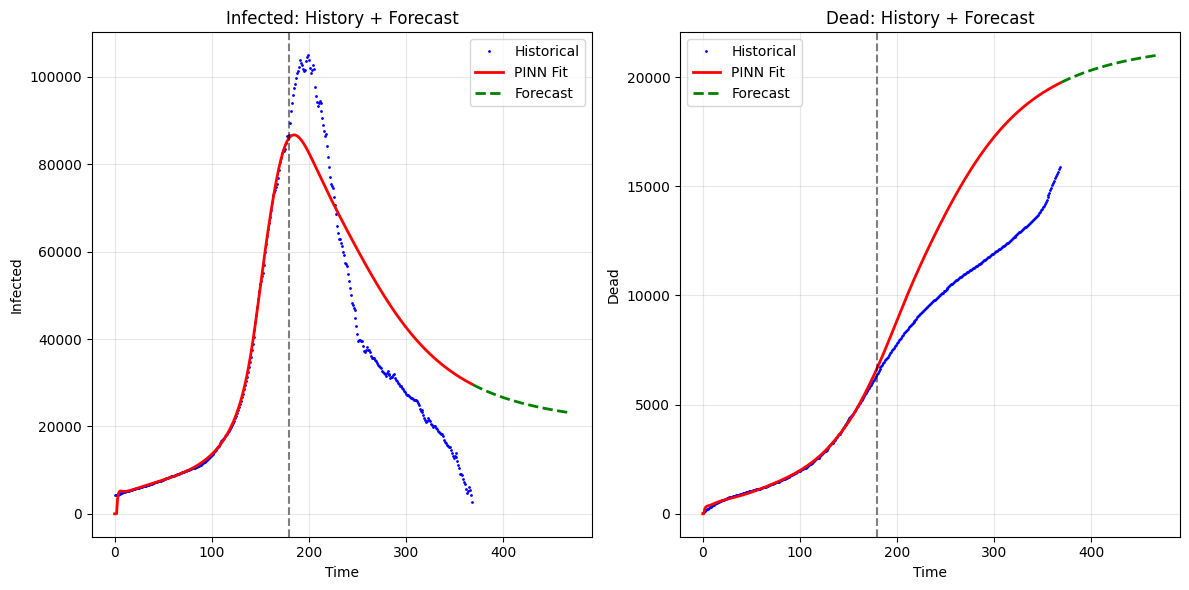

In [198]:
print("\nОтрисовка результатов...")
plot_results(timesteps, train_size, S, I, R, D, S_pred, I_pred, R_pred, D_pred, final_params)
    
# Отрисовка потерь
plot_losses(model.losses)
    
# Вычисление метрик
metrics = calculate_metrics(S, I, R, D, S_pred, I_pred, R_pred, D_pred, train_size)
    
# Если у вас есть истинные параметры, можно сравнить
# true_params = {'beta': 0.3, 'gamma': 0.1, 'mu': 0.01}  # замените на ваши
# plot_params_comparison(true_params, final_params)
    
print("\nГотово! Результаты сохранены:")
print("- sird_prediction_results.png")
print("- training_loss.png")
    
# Дополнительно: предсказание на будущее
future_steps = 100
future_t = np.arange(len(timesteps), len(timesteps) + future_steps)
S_future, I_future, R_future, D_future = model.predict(future_t)
    
# Визуализация с прогнозом
plt.figure(figsize=(12, 6))
    
plt.subplot(1, 2, 1)
plt.plot(timesteps, I, 'b.', label='Historical', markersize=2)
plt.plot(timesteps, I_pred, 'r-', label='PINN Fit', linewidth=2)
plt.plot(future_t, I_future.numpy(), 'g--', label='Forecast', linewidth=2)
plt.axvline(x=train_size-0.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Infected')
plt.title('Infected: History + Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
    
plt.subplot(1, 2, 2)
plt.plot(timesteps, D, 'b.', label='Historical', markersize=2)
plt.plot(timesteps, D_pred, 'r-', label='PINN Fit', linewidth=2)
plt.plot(future_t, D_future.numpy(), 'g--', label='Forecast', linewidth=2)
plt.axvline(x=train_size-0.5, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Dead')
plt.title('Dead: History + Forecast')
plt.legend()
plt.grid(True, alpha=0.3)
    
plt.tight_layout()
# plt.savefig('forecast_results.png', dpi=150)
plt.show()
    
# print("\nДополнительный прогноз сохранен в forecast_results.png")